In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.ticker as mticker
import seaborn as sns
import platform

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import GridSearchCV


if platform.system() == 'Darwin':  # 맥
    plt.rcParams['font.family'] = 'AppleGothic'
elif platform.system() == 'Windows':  # 윈도우
    plt.rcParams['font.family'] = 'Malgun Gothic'
else:  # 리눅스 등
    plt.rcParams['font.family'] = 'NanumGothic'

mpl.rcParams['axes.unicode_minus'] = False


In [2]:
BASE_PATH = './'

FILE_INFO = [
    ('2023_강남.csv', '강남구', 2023),
    ('2023_노원.csv', '노원구', 2023),
    ('2023_성동.csv', '성동구', 2023),
    ('2024_강남.csv', '강남구', 2024),
    ('2024_노원.csv', '노원구', 2024),
    ('2024_성동.csv', '성동구', 2024),
    ('2025_강남.csv', '강남구', 2025),
    ('2025_노원.csv', '노원구', 2025),
    ('2025_성동.csv', '성동구', 2025),
]

dfs = []

for fname, district, year in FILE_INFO:
    file_path = BASE_PATH + fname
    
    temp_df = pd.read_csv(
        file_path,
        encoding='cp949',
        skiprows=15,
        header=0,
        on_bad_lines='skip'
    )
    
    # 원본 행 수 저장
    before_count = len(temp_df)
    
    # 시군구 컬럼에서 실제 자치구 추출
    # 예: "서울특별시 강남구 역삼동" → "강남구"
    temp_df['실제자치구'] = temp_df['시군구'].astype(str).str.split().str[1]
    
    # 파일명 기준 자치구와 실제 시군구의 자치구가 일치하는 행만 남김
    # 예: 성동구 파일 안에 신당동/중구 데이터가 섞여 있으면 제거됨
    temp_df = temp_df[temp_df['실제자치구'] == district].copy()
    
    # 분석용 자치구, 연도, 원본파일 컬럼 추가
    temp_df['자치구'] = district
    temp_df['연도'] = year
    temp_df['원본파일'] = fname
    
    # 동명 추출
    temp_df['동명'] = temp_df['시군구'].astype(str).str.split().str[-1]
    
    after_count = len(temp_df)
    removed_count = before_count - after_count
    
    dfs.append(temp_df)
    
    print(f'{fname}: {after_count:,}건 로드 / 제거 {removed_count:,}건')

raw_df = pd.concat(dfs, ignore_index=True)

print(f'\n전체 데이터: {len(raw_df):,}건')
raw_df.head(3)

2023_강남.csv: 2,339건 로드 / 제거 0건
2023_노원.csv: 2,653건 로드 / 제거 0건
2023_성동.csv: 1,565건 로드 / 제거 0건
2024_강남.csv: 3,754건 로드 / 제거 0건
2024_노원.csv: 4,210건 로드 / 제거 1건
2024_성동.csv: 2,885건 로드 / 제거 2건
2025_강남.csv: 4,315건 로드 / 제거 0건
2025_노원.csv: 5,797건 로드 / 제거 0건
2025_성동.csv: 4,709건 로드 / 제거 1건

전체 데이터: 32,227건


,NO,시군구,번지,본번,부번,단지명,전용면적(㎡),계약년월,계약일,거래금액(만원),...,도로명,해제사유발생일,거래유형,중개사소재지,등기일자,실제자치구,자치구,연도,원본파일,동명
0,1.0,서울특별시 강남구 개포동,12,12.0,0.0,삼익대청아파트,60.00,202312.0,31.0,"162,500",...,개포로109길 21,-,중개거래,서울 강남구,24.01.22,강남구,강남구,2023,2023_강남.csv,개포동
1,2.0,서울특별시 강남구 역삼동,757,757.0,0.0,역삼래미안,59.53,202312.0,31.0,"182,000",...,선릉로69길 19,-,중개거래,서울 강남구,24.03.22,강남구,강남구,2023,2023_강남.csv,역삼동
2,3.0,서울특별시 강남구 대치동,1027,1027.0,0.0,래미안대치팰리스,84.98,202312.0,30.0,"323,000",...,삼성로51길 37,-,중개거래,서울 강남구,24.02.29,강남구,강남구,2023,2023_강남.csv,대치동


In [3]:
# ============================================================
# 2. 데이터 전처리
# ============================================================

df = raw_df.copy()

# 거래금액: 쉼표 제거 후 숫자 변환
df['거래금액(만원)'] = (
    df['거래금액(만원)']
    .astype(str)
    .str.replace(',', '', regex=False)
    .str.strip()
)
df['거래금액(만원)'] = pd.to_numeric(df['거래금액(만원)'], errors='coerce')

# 계약년월 숫자 변환 후 계약년, 계약월 생성
df['계약년월'] = pd.to_numeric(df['계약년월'], errors='coerce')
df = df.dropna(subset=['계약년월']).copy()

df['계약년월'] = df['계약년월'].astype(int)
df['계약년'] = df['계약년월'] // 100
df['계약월'] = df['계약년월'] % 100

# 건축년도 숫자 변환 후 건물연식 생성
df['건축년도'] = pd.to_numeric(df['건축년도'], errors='coerce')
df['건물연식'] = df['계약년'] - df['건축년도']

# 층, 전용면적 숫자 변환
df['층'] = pd.to_numeric(df['층'], errors='coerce')
df['전용면적(㎡)'] = pd.to_numeric(df['전용면적(㎡)'], errors='coerce')

# 중개거래만 사용
df = df[df['거래유형'] == '중개거래'].copy()

# 해제 거래 제거
df = df[df['해제사유발생일'].isna() | (df['해제사유발생일'] == '-')].copy()

# 핵심 컬럼 결측치 제거
core_cols = [
    '거래금액(만원)',
    '전용면적(㎡)',
    '층',
    '건물연식',
    '건축년도',
    '계약년',
    '계약월',
    '자치구',
    '동명'
]

print("== 결측치 확인 ==")
print(df[core_cols].isnull().sum())

df = df.dropna(subset=core_cols).copy()

df.head()


== 결측치 확인 ==
거래금액(만원)    0
전용면적(㎡)     0
층           0
건물연식        0
건축년도        0
계약년         0
계약월         0
자치구         0
동명          0
dtype: int64


,NO,시군구,번지,본번,부번,단지명,전용면적(㎡),계약년월,계약일,거래금액(만원),...,중개사소재지,등기일자,실제자치구,자치구,연도,원본파일,동명,계약년,계약월,건물연식
0,1.0,서울특별시 강남구 개포동,12,12.0,0.0,삼익대청아파트,60.00,202312,31.0,162500,...,서울 강남구,24.01.22,강남구,강남구,2023,2023_강남.csv,개포동,2023,12,31.0
1,2.0,서울특별시 강남구 역삼동,757,757.0,0.0,역삼래미안,59.53,202312,31.0,182000,...,서울 강남구,24.03.22,강남구,강남구,2023,2023_강남.csv,역삼동,2023,12,18.0
2,3.0,서울특별시 강남구 대치동,1027,1027.0,0.0,래미안대치팰리스,84.98,202312,30.0,323000,...,서울 강남구,24.02.29,강남구,강남구,2023,2023_강남.csv,대치동,2023,12,8.0
4,5.0,서울특별시 강남구 청담동,60,60.0,0.0,삼성청담공원아파트,107.22,202312,30.0,210000,...,서울 강남구,24.03.18,강남구,강남구,2023,2023_강남.csv,청담동,2023,12,24.0
5,6.0,서울특별시 강남구 도곡동,952,952.0,0.0,대우디오빌,25.89,202312,30.0,25700,...,서울 강남구,24.02.05,강남구,강남구,2023,2023_강남.csv,도곡동,2023,12,19.0


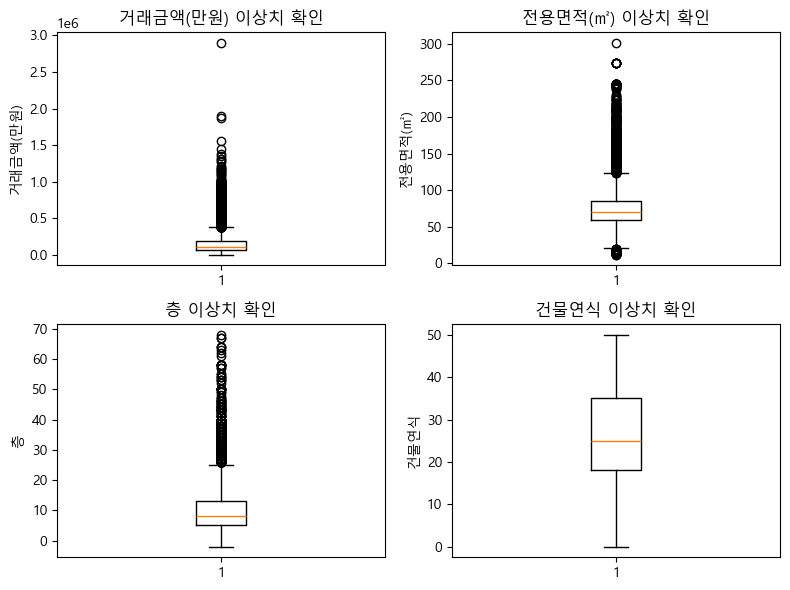

,전용면적(㎡),거래금액(만원),층,건물연식
count,29038.000000,2.903800e+04,29038.000000,29038.000000
mean,75.518692,1.498623e+05,9.202734,24.841311
std,30.397250,1.284226e+05,6.237738,11.199996
min,12.100000,7.500000e+03,-2.000000,0.000000
25%,59.220000,6.300000e+04,5.000000,18.000000
50%,70.810000,1.135000e+05,8.000000,25.000000
75%,84.956975,1.900000e+05,13.000000,35.000000
max,301.470000,2.900000e+06,68.000000,50.000000


In [4]:
# ============================================================
# 3. 이상치 분포 확인
# ============================================================

cols = ['거래금액(만원)', '전용면적(㎡)', '층', '건물연식']

plt.figure(figsize=(8, 6))

for i, col in enumerate(cols, 1):
    plt.subplot(2, 2, i)
    plt.boxplot(df[col].dropna())
    plt.title(col + ' 이상치 확인')
    plt.ylabel(col)

plt.tight_layout()
plt.show()

df[['전용면적(㎡)', '거래금액(만원)', '층', '건물연식']].describe()

In [5]:
# 이상치 제거
df = df[df['층'] > 0].copy()
df = df[df['전용면적(㎡)'] >= 10].copy()
df = df[df['거래금액(만원)'] >= 10000].copy()
df = df[df['건물연식'] >= 0].copy()

df = df.reset_index(drop=True)

print(f'전처리 후 데이터: {len(df):,}건')
print('\n자치구별 건수:')
print(df['자치구'].value_counts())

전처리 후 데이터: 29,015건

자치구별 건수:
자치구
노원구    11523
강남구     9374
성동구     8118
Name: count, dtype: int64


In [6]:
# ============================================================
# 4. 역세권여부 변수 생성
# ============================================================

STATION_AREA = {
    # 강남구
    '개포동': 1, '논현동': 1, '대치동': 1, '도곡동': 1, '삼성동': 1,
    '수서동': 1, '신사동': 1, '압구정동': 1, '역삼동': 1, '일원동': 1, '청담동': 1,
    '세곡동': 0, '율현동': 0, '자곡동': 0,

    # 노원구
    '공릉동': 1, '상계동': 1, '월계동': 1, '중계동': 1, '하계동': 1,

    # 성동구
    '금호동1가': 1, '금호동2가': 1, '금호동3가': 1, '금호동4가': 1,
    '도선동': 0, '마장동': 1, '사근동': 0, '상왕십리동': 1,
    '성수동1가': 1, '성수동2가': 1, '옥수동': 1, '용답동': 1,
    '응봉동': 1, '하왕십리동': 1, '행당동': 1, '홍익동': 0,
    '송정동': 0,
}

df['역세권여부'] = df['동명'].map(STATION_AREA).fillna(0).astype(int)

print('역세권여부 생성 완료')
print(df.groupby(['자치구', '역세권여부'])['거래금액(만원)'].count())

역세권여부 생성 완료
자치구  역세권여부
강남구  0          658
     1         8716
노원구  1        11523
성동구  0          177
     1         7941
Name: 거래금액(만원), dtype: int64


In [7]:
# ============================================================
# 5. 학원 데이터 로드 및 구별 학원 수 집계
# ============================================================

df_academy = pd.read_csv('./학원.csv', encoding='cp949')

# 분석 대상 3개 구만 필터링
df_academy_count = df_academy[
    df_academy['행정구역명'].isin(['강남구', '노원구', '성동구'])
]

# 구별 학원 수 집계
df_academy_count = df_academy_count.groupby('행정구역명').size().reset_index()
df_academy_count.columns = ['자치구', '학원수']

# 아파트 데이터에 학원수 병합
df = df.merge(df_academy_count, on='자치구', how='left')

# 결측치 처리
df['학원수'] = df['학원수'].fillna(0)

print('구별 학원수:')
print(df.groupby('자치구')['학원수'].first())

구별 학원수:
자치구
강남구    3441
노원구    1427
성동구     574
Name: 학원수, dtype: int64


In [8]:
# ============================================================
# 6. 사업체 데이터 확인
# ============================================================

business_dong_path = BASE_PATH + 'business_size_dong.csv'

business_check = pd.read_csv(
    business_dong_path,
    encoding='utf-8-sig',
    skiprows=4,
    header=None
)

print('사업체 동별 데이터 크기:', business_check.shape)
display(business_check.head())

사업체 동별 데이터 크기: (60, 26)


,0,1,2,3,4,5,6,7,8,9,...,16,17,18,19,20,21,22,23,24,25
0,합계,성동구,소계,39264,13180,201023,111482,89541,31823,46864,...,276,19331,144,23758,21,7594,18,12992,5,10940
1,합계,성동구,왕십리2동,1217,517,2619,1258,1361,1099,1449,...,3,188,-,-,-,-,-,-,-,-
2,합계,성동구,왕십리도선동,3165,1304,9832,4513,5319,2750,3856,...,11,764,6,1103,-,-,-,-,-,-
3,합계,성동구,마장동,3911,1049,12829,8436,4393,3404,5060,...,12,763,5,781,1,365,2,1737,-,-
4,합계,성동구,사근동,1265,411,11126,5162,5964,1069,1656,...,7,471,3,595,-,-,3,2035,2,4674


In [9]:
# ============================================================
# 사업체 데이터 컬럼 정리
# - 1번 컬럼: 자치구
# - 2번 컬럼: 행정동명
# - 3번 컬럼: 전체 사업체수
# - 5번 컬럼: 전체 종사자수
# ============================================================

business_dong = business_check[[1, 2, 3, 5]].copy()
business_dong.columns = ['자치구', '행정동명', '동별_사업체수_전체', '동별_종사자수_전체']

# 분석 대상 3개 구만 필터링
business_dong = business_dong[
    business_dong['자치구'].isin(['강남구', '노원구', '성동구'])
].copy()

# 소계 행 제거
business_dong = business_dong[business_dong['행정동명'] != '소계'].copy()

# 숫자형 변환
for col in ['동별_사업체수_전체', '동별_종사자수_전체']:
    business_dong[col] = (
        business_dong[col]
        .astype(str)
        .str.replace(',', '', regex=False)
        .str.replace('-', '0', regex=False)
        .str.strip()
    )
    business_dong[col] = pd.to_numeric(business_dong[col], errors='coerce')

business_dong = business_dong.dropna(
    subset=['동별_사업체수_전체', '동별_종사자수_전체']
).copy()

print('정리 후 사업체 데이터:', business_dong.shape)
display(business_dong.head(20))

정리 후 사업체 데이터: (58, 4)


,자치구,행정동명,동별_사업체수_전체,동별_종사자수_전체
1,성동구,왕십리2동,1217,2619
2,성동구,왕십리도선동,3165,9832
3,성동구,마장동,3911,12829
4,성동구,사근동,1265,11126
5,성동구,행당1동,1640,10704
6,성동구,행당2동,1024,2339
7,성동구,응봉동,655,1108
8,성동구,금호1가동,914,2156
9,성동구,금호2.3가동,1489,2943
10,성동구,금호4가동,989,2219


In [10]:
# ============================================================
# 사업체 데이터의 행정동명을 아파트 데이터의 법정동명 기준으로 변환
# ============================================================

def convert_to_apt_dong(name):
    name = str(name).strip()

    # 강남구
    if name.startswith('개포'):
        return '개포동'
    elif name.startswith('역삼'):
        return '역삼동'
    elif name.startswith('대치'):
        return '대치동'
    elif name.startswith('청담'):
        return '청담동'
    elif name.startswith('도곡'):
        return '도곡동'
    elif name.startswith('삼성'):
        return '삼성동'
    elif name.startswith('일원'):
        return '일원동'
    elif name.startswith('논현'):
        return '논현동'
    elif name.startswith('압구정'):
        return '압구정동'
    elif name.startswith('신사'):
        return '신사동'
    elif name.startswith('수서'):
        return '수서동'
    elif name.startswith('세곡'):
        return '세곡동'
    elif name.startswith('자곡'):
        return '자곡동'
    elif name.startswith('율현'):
        return '율현동'

    # 노원구
    elif name.startswith('상계'):
        return '상계동'
    elif name.startswith('중계'):
        return '중계동'
    elif name.startswith('하계'):
        return '하계동'
    elif name.startswith('월계'):
        return '월계동'
    elif name.startswith('공릉'):
        return '공릉동'

    # 성동구
    elif name.startswith('마장'):
        return '마장동'
    elif name.startswith('사근'):
        return '사근동'
    elif name.startswith('행당'):
        return '행당동'
    elif name.startswith('응봉'):
        return '응봉동'
    elif name.startswith('옥수'):
        return '옥수동'
    elif name.startswith('송정'):
        return '송정동'
    elif name.startswith('용답'):
        return '용답동'
    elif name.startswith('하왕십리'):
        return '하왕십리동'
    elif name.startswith('상왕십리'):
        return '상왕십리동'
    elif name.startswith('왕십리2'):
        return '하왕십리동'
    elif name.startswith('왕십리도선'):
        return '도선동'
    elif name.startswith('성수1가'):
        return '성수동1가'
    elif name.startswith('성수2가'):
        return '성수동2가'
    elif name.startswith('금호1가'):
        return '금호동1가'
    elif name.startswith('금호2') or name.startswith('금호3'):
        return '금호동2가'
    elif name.startswith('금호4가'):
        return '금호동4가'

    return name

business_dong['동명'] = business_dong['행정동명'].apply(convert_to_apt_dong)

display(
    business_dong[
        ['자치구', '행정동명', '동명', '동별_사업체수_전체', '동별_종사자수_전체']
    ].head()
)

,자치구,행정동명,동명,동별_사업체수_전체,동별_종사자수_전체
1,성동구,왕십리2동,하왕십리동,1217,2619
2,성동구,왕십리도선동,도선동,3165,9832
3,성동구,마장동,마장동,3911,12829
4,성동구,사근동,사근동,1265,11126
5,성동구,행당1동,행당동,1640,10704


In [11]:
# ============================================================
# 법정동 기준 사업체 변수 집계
# ============================================================

business_dong_final = (
    business_dong
    .groupby(['자치구', '동명'])[
        ['동별_사업체수_전체', '동별_종사자수_전체']
    ]
    .sum()
    .reset_index()
)

# 사업체당 종사자수 생성
business_dong_final['사업체당종사자수'] = (
    business_dong_final['동별_종사자수_전체'] /
    business_dong_final['동별_사업체수_전체']
)

business_dong_final['사업체당종사자수'] = (
    business_dong_final['사업체당종사자수']
    .replace([np.inf, -np.inf], 0)
    .fillna(0)
)

# 모델에서 사용할 컬럼명 단순화
business_dong_final = business_dong_final.rename(columns={
    '동별_사업체수_전체': '사업체수',
    '동별_종사자수_전체': '종사자수'
})

print('최종 동별 사업체 데이터:', business_dong_final.shape)
display(business_dong_final.head(30))

최종 동별 사업체 데이터: (31, 5)


,자치구,동명,사업체수,종사자수,사업체당종사자수
0,강남구,개포동,5838,24931,4.270469
1,강남구,논현동,16413,119323,7.270030
2,강남구,대치동,12315,99194,8.054730
3,강남구,도곡동,5103,39795,7.798354
4,강남구,삼성동,12975,112349,8.658882
5,강남구,세곡동,2681,10206,3.806789
6,강남구,수서동,1746,16635,9.527491
7,강남구,신사동,5590,26166,4.680859
8,강남구,압구정동,5491,32040,5.835003
9,강남구,역삼동,23750,217332,9.150821


In [12]:
# ============================================================
# 아파트 데이터에 사업체 변수 병합
# ============================================================

before_merge = len(df)

df = df.merge(
    business_dong_final[
        ['자치구', '동명', '사업체수', '종사자수', '사업체당종사자수']
    ],
    on=['자치구', '동명'],
    how='left'
)

after_merge = len(df)

print(f'병합 전: {before_merge:,}건')
print(f'병합 후: {after_merge:,}건')

df['사업체수'] = df['사업체수'].fillna(0)
df['종사자수'] = df['종사자수'].fillna(0)
df['사업체당종사자수'] = df['사업체당종사자수'].fillna(0)

print('사업체수 매칭률:', round((df['사업체수'] != 0).mean() * 100, 2), '%')

display(
    df[['자치구', '동명', '사업체수', '종사자수', '사업체당종사자수']]
    .drop_duplicates()
    .sort_values(['자치구', '동명'])
    .head(50)
)

병합 전: 29,015건
병합 후: 29,015건
사업체수 매칭률: 96.83 %


,자치구,동명,사업체수,종사자수,사업체당종사자수
0,강남구,개포동,5838.0,24931.0,4.270469
24,강남구,논현동,16413.0,119323.0,7.270030
2,강남구,대치동,12315.0,99194.0,8.054730
4,강남구,도곡동,5103.0,39795.0,7.798354
9,강남구,삼성동,12975.0,112349.0,8.658882
19,강남구,세곡동,2681.0,10206.0,3.806789
11,강남구,수서동,1746.0,16635.0,9.527491
33,강남구,신사동,5590.0,26166.0,4.680859
21,강남구,압구정동,5491.0,32040.0,5.835003
1,강남구,역삼동,23750.0,217332.0,9.150821


In [13]:
# ============================================================
# 7. 변수 생성 결과 확인
# ============================================================

check_cols = [
    '자치구', '동명', '거래금액(만원)',
    '전용면적(㎡)', '층', '건물연식',
    '계약년', '계약월',
    '역세권여부',       # Model B
    '학원수',           # Model C
    '사업체수',         # Model D, E
    '사업체당종사자수'  # Model D, E
]
print('== 변수 생성 결과 확인 ==')
df[check_cols].head()

== 변수 생성 결과 확인 ==


,자치구,동명,거래금액(만원),전용면적(㎡),층,건물연식,계약년,계약월,역세권여부,학원수,사업체수,사업체당종사자수
0,강남구,개포동,162500,60.00,8.0,31.0,2023,12,1,3441,5838.0,4.270469
1,강남구,역삼동,182000,59.53,17.0,18.0,2023,12,1,3441,23750.0,9.150821
2,강남구,대치동,323000,84.98,18.0,8.0,2023,12,1,3441,12315.0,8.054730
3,강남구,청담동,210000,107.22,11.0,24.0,2023,12,1,3441,6005.0,6.781682
4,강남구,도곡동,25700,25.89,12.0,19.0,2023,12,1,3441,5103.0,7.798354


In [14]:
print(df[['역세권여부', '학원수', '사업체수', '사업체당종사자수']].describe())

              역세권여부           학원수          사업체수      사업체당종사자수
count  29015.000000  29015.000000  29015.000000  29015.000000
mean       0.971222   1839.013855   7430.596381      4.428077
std        0.167186   1159.447510   6377.613220      2.257797
min        0.000000    574.000000      0.000000      0.000000
25%        1.000000    574.000000   2490.000000      3.280235
50%        1.000000   1427.000000   5838.000000      3.327148
75%        1.000000   3441.000000  12315.000000      5.544190
max        1.000000   3441.000000  23750.000000      9.527491


In [15]:
# 결측치 확인
df[check_cols].isnull().sum()

자치구         0
동명          0
거래금액(만원)    0
전용면적(㎡)     0
층           0
건물연식        0
계약년         0
계약월         0
역세권여부       0
학원수         0
사업체수        0
사업체당종사자수    0
dtype: int64

C:\Users\weg04\AppData\Local\Temp\ipykernel_36648\3233307494.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_box, labels=gulist, patch_artist=True, showfliers=False)


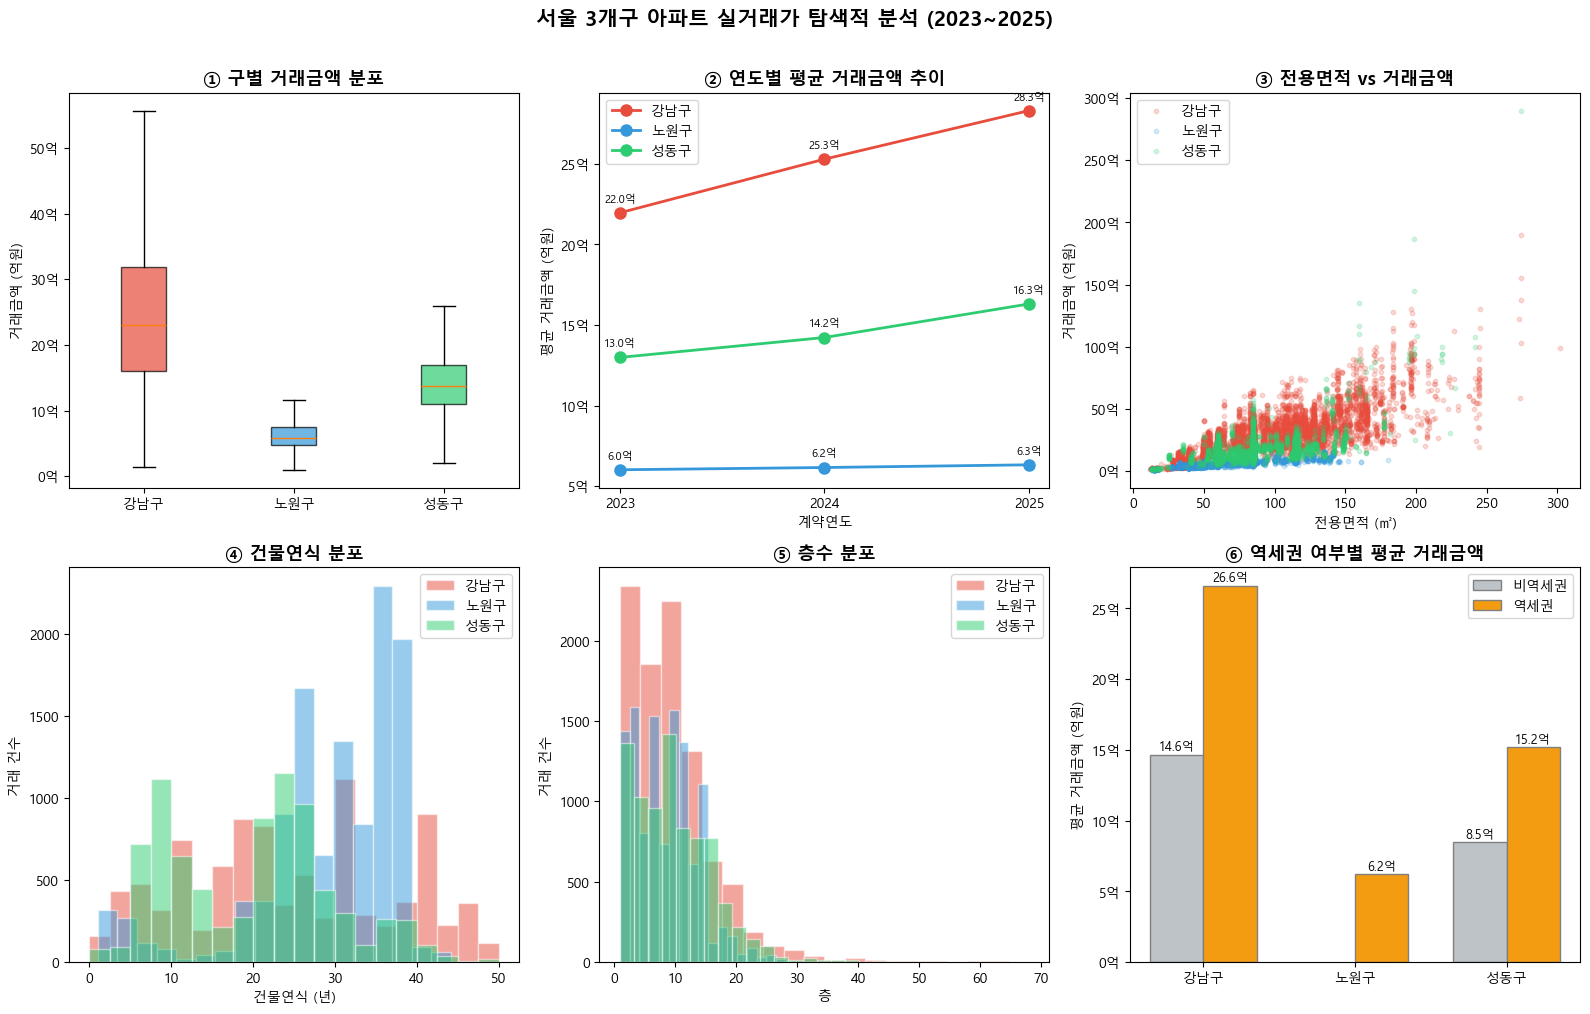

In [16]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
colors = {'강남구': '#E74C3C', '노원구': '#3498DB', '성동구': '#2ECC71'}
gulist = ['강남구', '노원구', '성동구']

# ① 구별 거래금액 분포 (박스플롯)
ax = axes[0, 0]
data_box = [df[df['자치구'] == gu]['거래금액(만원)'].dropna() / 10000 for gu in gulist]
bp = ax.boxplot(data_box, labels=gulist, patch_artist=True, showfliers=False)
for patch, color in zip(bp['boxes'], colors.values()):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_title('① 구별 거래금액 분포', fontsize=13, fontweight='bold')
ax.set_ylabel('거래금액 (억원)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}억'))

# ② 연도별 평균 거래금액 추이 (값 표시 추가)
ax = axes[0, 1]
yearly = df.groupby(['계약년', '자치구'])['거래금액(만원)'].mean().reset_index()
for gu, color in colors.items():
    sub = yearly[yearly['자치구'] == gu]
    ax.plot(sub['계약년'], sub['거래금액(만원)'] / 10000,
            marker='o', label=gu, color=color, linewidth=2, markersize=8)
    for _, row in sub.iterrows():
        ax.annotate(f'{row["거래금액(만원)"]/10000:.1f}억',
                   (row['계약년'], row['거래금액(만원)']/10000),
                   textcoords='offset points', xytext=(0, 8), fontsize=8, ha='center')
ax.set_title('② 연도별 평균 거래금액 추이', fontsize=13, fontweight='bold')
ax.set_ylabel('평균 거래금액 (억원)')
ax.set_xlabel('계약연도')
ax.legend()
ax.set_xticks([2023, 2024, 2025])
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}억'))

# ③ 전용면적 vs 거래금액 산점도 (전체 데이터 사용)
ax = axes[0, 2]
for gu, color in colors.items():
    sub = df[df['자치구'] == gu]
    ax.scatter(sub['전용면적(㎡)'], sub['거래금액(만원)'] / 10000,
               alpha=0.2, label=gu, color=color, s=10)
ax.set_title('③ 전용면적 vs 거래금액', fontsize=13, fontweight='bold')
ax.set_xlabel('전용면적 (㎡)')
ax.set_ylabel('거래금액 (억원)')
ax.legend()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}억'))

# ④ 건물연식 분포 (기존 유지)
ax = axes[1, 0]
for gu, color in colors.items():
    sub = df[df['자치구'] == gu]['건물연식']
    ax.hist(sub, bins=20, alpha=0.5, label=gu, color=color, edgecolor='white')
ax.set_title('④ 건물연식 분포', fontsize=13, fontweight='bold')
ax.set_xlabel('건물연식 (년)')
ax.set_ylabel('거래 건수')
ax.legend()

# ⑤ 층수 분포 (기존 유지)
ax = axes[1, 1]
for gu, color in colors.items():
    sub = df[df['자치구'] == gu]['층']
    ax.hist(sub, bins=20, alpha=0.5, label=gu, color=color, edgecolor='white')
ax.set_title('⑤ 층수 분포', fontsize=13, fontweight='bold')
ax.set_xlabel('층')
ax.set_ylabel('거래 건수')
ax.legend()

# ⑥ 역세권 여부별 평균 거래금액 (값 표시 추가)
ax = axes[1, 2]
station_mean = df.groupby(['자치구', '역세권여부'])['거래금액(만원)'].mean().unstack() / 10000
x = np.arange(len(gulist))
width = 0.35
bars0 = ax.bar(x - width/2,
               [station_mean.loc[gu, 0] if 0 in station_mean.columns else 0 for gu in gulist],
               width, label='비역세권', color='#BDC3C7', edgecolor='gray')
bars1 = ax.bar(x + width/2,
               [station_mean.loc[gu, 1] if 1 in station_mean.columns else 0 for gu in gulist],
               width, label='역세권', color='#F39C12', edgecolor='gray')
for bar in bars0:
    h = bar.get_height()
    if h > 0:
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.3,
                f'{h:.1f}억', ha='center', fontsize=9)
for bar in bars1:
    h = bar.get_height()
    if h > 0:
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.3,
                f'{h:.1f}억', ha='center', fontsize=9)
ax.set_title('⑥ 역세권 여부별 평균 거래금액', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(gulist)
ax.set_ylabel('평균 거래금액 (억원)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}억'))
ax.legend()

plt.suptitle('서울 3개구 아파트 실거래가 탐색적 분석 (2023~2025)',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

EDA - 3개구 비교


C:\Users\weg04\AppData\Local\Temp\ipykernel_36648\209963035.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(data_by_district, labels=districts)


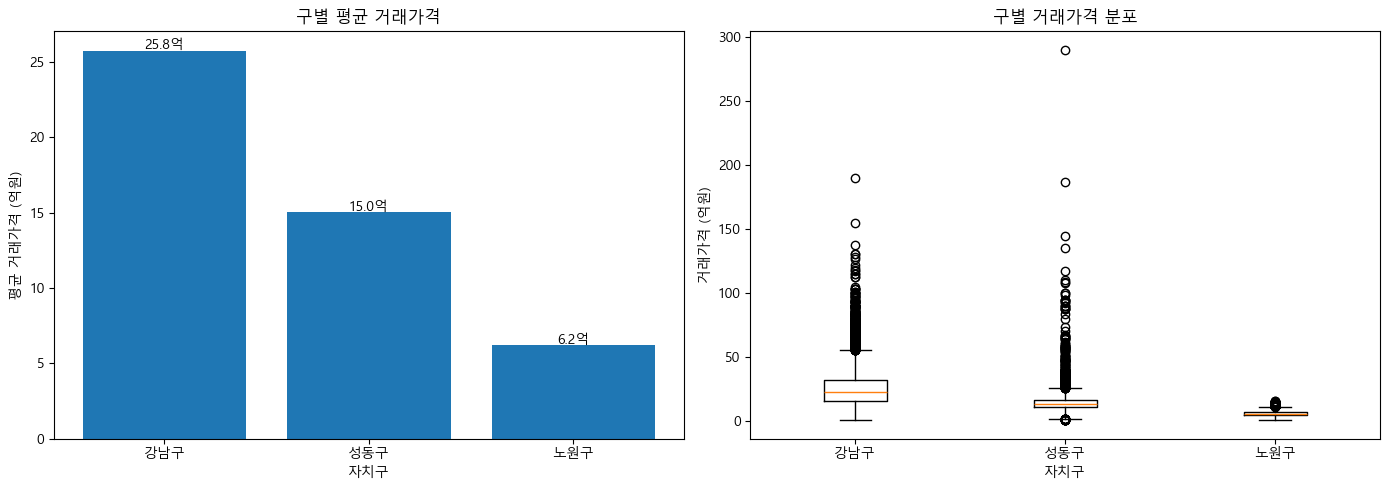

구별 평균/중간 거래가격 (만원):
         mean    median  count
자치구                           
강남구  257546.0  229850.0   9374
노원구   62074.0   58000.0  11523
성동구  150411.0  138000.0   8118


In [17]:
# ============================================================
# EDA 1. 구별 아파트 평균 거래가격 비교
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

mean_price = df.groupby('자치구')['거래금액(만원)'].mean().sort_values(ascending=False)
axes[0].bar(mean_price.index, mean_price.values / 10000)
axes[0].set_title('구별 평균 거래가격')
axes[0].set_xlabel('자치구')
axes[0].set_ylabel('평균 거래가격 (억원)')
for i, v in enumerate(mean_price.values / 10000):
    axes[0].text(i, v + 0.1, f'{v:.1f}억', ha='center')

districts = ['강남구', '성동구', '노원구']
data_by_district = [df[df['자치구'] == d]['거래금액(만원)'].dropna() / 10000 for d in districts]
axes[1].boxplot(data_by_district, labels=districts)
axes[1].set_title('구별 거래가격 분포')
axes[1].set_xlabel('자치구')
axes[1].set_ylabel('거래가격 (억원)')

plt.tight_layout()
plt.show()

print('구별 평균/중간 거래가격 (만원):')
print(df.groupby('자치구')['거래금액(만원)'].agg(['mean', 'median', 'count']).round(0))


1. 구별 평균 거래가격

- 강남구(25.8억) > 성동구(15.0억) > 노원구(6.2억)로 뚜렷한 계층 구조가 보인다. boxplot에서 강남구의 분포 폭이 가장 넓고 이상치도 많은데, 이는 초고가 아파트가 섞여 있기 때문이다. 노원구는 분포가 매우 좁고 일관된 가격대를 보인다.


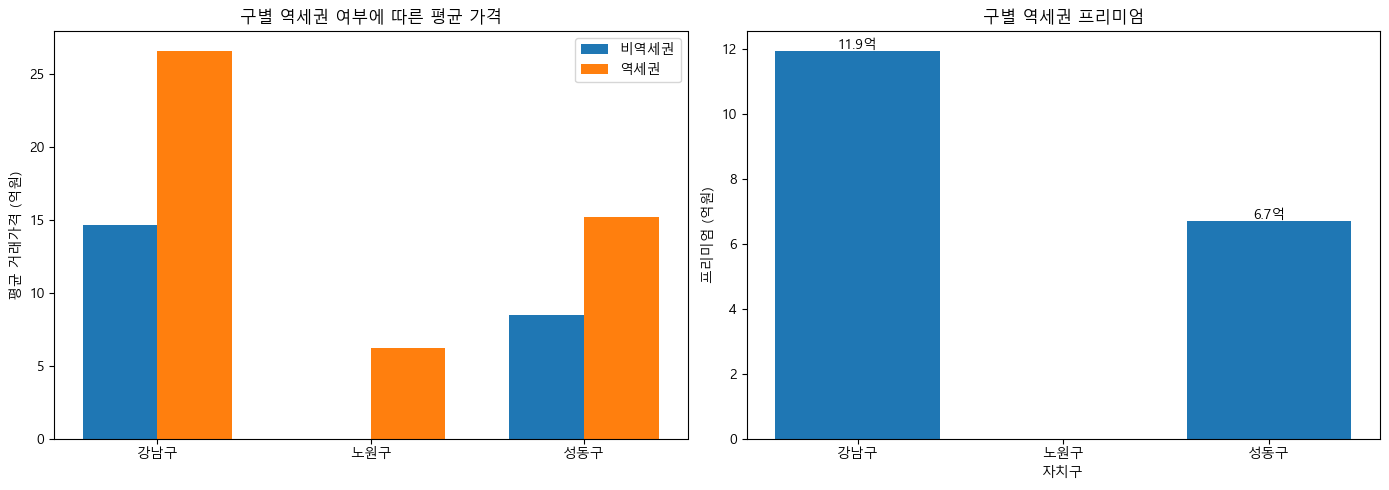

구별 역세권 프리미엄 (억원):
      비역세권    역세권   프리미엄
자치구                     
강남구  14.64  26.59  11.95
노원구    NaN   6.21    NaN
성동구   8.48  15.19   6.71


In [18]:
# ============================================================
# EDA 2. 구별 역세권 프리미엄 비교
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

station_price = df.groupby(['자치구', '역세권여부'])['거래금액(만원)'].mean().unstack() / 10000
station_price.columns = ['비역세권', '역세권']
x = range(len(station_price))
width = 0.35
axes[0].bar([i - width/2 for i in x], station_price['비역세권'], width, label='비역세권')
axes[0].bar([i + width/2 for i in x], station_price['역세권'], width, label='역세권')
axes[0].set_title('구별 역세권 여부에 따른 평균 가격')
axes[0].set_xticks(list(x))
axes[0].set_xticklabels(station_price.index)
axes[0].set_ylabel('평균 거래가격 (억원)')
axes[0].legend()

station_price['프리미엄'] = station_price['역세권'] - station_price['비역세권']
axes[1].bar(station_price.index, station_price['프리미엄'])
axes[1].set_title('구별 역세권 프리미엄')
axes[1].set_xlabel('자치구')
axes[1].set_ylabel('프리미엄 (억원)')
for i, v in enumerate(station_price['프리미엄']):
    axes[1].text(i, v + 0.05, f'{v:.1f}억', ha='center')

plt.tight_layout()
plt.show()

print('구별 역세권 프리미엄 (억원):')
print(station_price.round(2))


2. 역세권 프리미엄

- 강남구 역세권 프리미엄(+11.9억)이 성동구(+6.7억)의 약 2배이다. 노원구는 비역세권 데이터가 사실상 없어서 NaN으로 나왔는데, 이는 노원구 아파트 대부분이 역세권에 위치한다는 의미이다. 역세권 프리미엄 자체가 구마다 다르다는 점이 중요한데, 역세권이라도 어느 구냐에 따라 가격이 전혀 다르다.


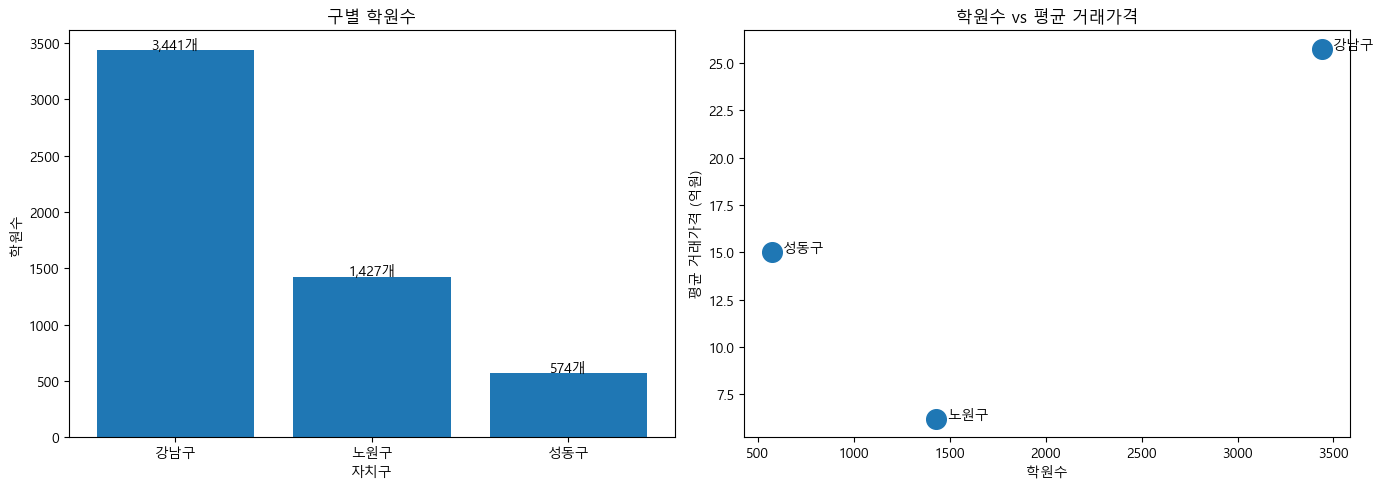

In [19]:
# ============================================================
# EDA 3. 구별 학원수 vs 평균 거래가격
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

academy_by_district = df.groupby('자치구')['학원수'].first().sort_values(ascending=False)
axes[0].bar(academy_by_district.index, academy_by_district.values)
axes[0].set_title('구별 학원수')
axes[0].set_xlabel('자치구')
axes[0].set_ylabel('학원수')
for i, v in enumerate(academy_by_district.values):
    axes[0].text(i, v + 10, f'{v:,.0f}개', ha='center')

district_summary = df.groupby('자치구').agg(
    평균가격=('거래금액(만원)', 'mean'),
    학원수=('학원수', 'first')
).reset_index()
district_summary['평균가격'] = district_summary['평균가격'] / 10000

axes[1].scatter(district_summary['학원수'], district_summary['평균가격'], s=200)
for _, row in district_summary.iterrows():
    axes[1].annotate(row['자치구'], (row['학원수'], row['평균가격']),
                     textcoords='offset points', xytext=(8, 0))
axes[1].set_title('학원수 vs 평균 거래가격')
axes[1].set_xlabel('학원수')
axes[1].set_ylabel('평균 거래가격 (억원)')

plt.tight_layout()
plt.show()


3. 학원수 vs 가격

- 학원수 순서는 강남(3,441) > 노원(1,427) > 성동(574)인데, 가격 순서는 강남 > 성동 > 노원이다. 노원구가 성동구보다 학원이 많지만 가격은 낮다. 산점도에서도 노원구가 이탈점으로 보인다. 학원수가 구 단위 집계라서 동 수준의 세밀한 차이를 반영하지 못하는 한계가 있다.


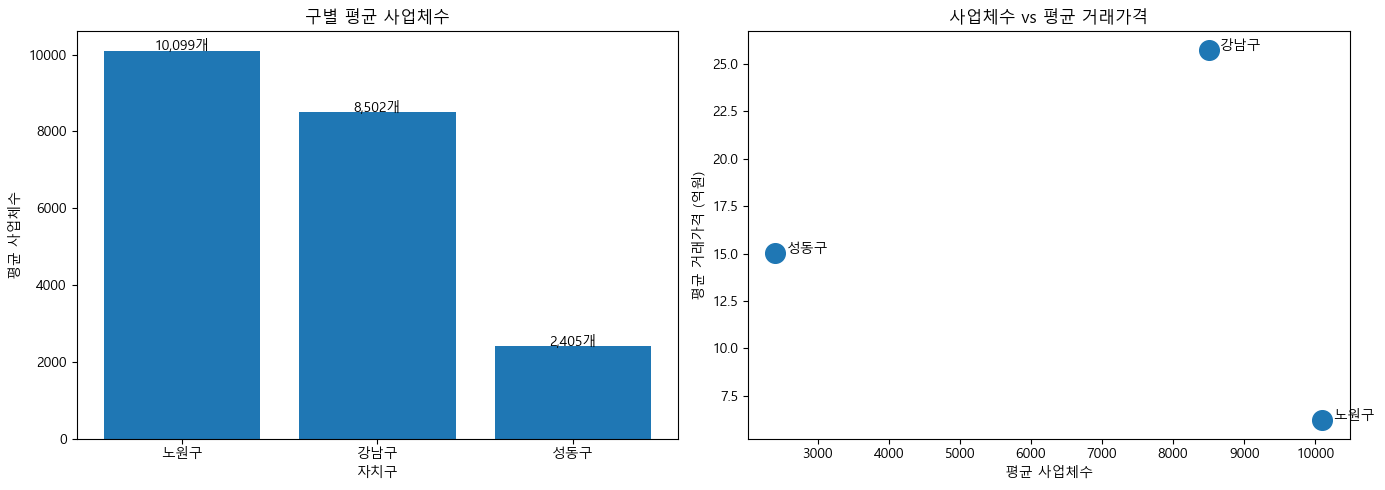

In [20]:
# ============================================================
# EDA 4. 구별 사업체수 vs 평균 거래가격
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

biz_by_district = df.groupby('자치구')['사업체수'].mean().sort_values(ascending=False)
axes[0].bar(biz_by_district.index, biz_by_district.values)
axes[0].set_title('구별 평균 사업체수')
axes[0].set_xlabel('자치구')
axes[0].set_ylabel('평균 사업체수')
for i, v in enumerate(biz_by_district.values):
    axes[0].text(i, v + 10, f'{v:,.0f}개', ha='center')

district_summary2 = df.groupby('자치구').agg(
    평균가격=('거래금액(만원)', 'mean'),
    사업체수=('사업체수', 'mean')
).reset_index()
district_summary2['평균가격'] = district_summary2['평균가격'] / 10000

axes[1].scatter(district_summary2['사업체수'], district_summary2['평균가격'], s=200)
for _, row in district_summary2.iterrows():
    axes[1].annotate(row['자치구'], (row['사업체수'], row['평균가격']),
                     textcoords='offset points', xytext=(8, 0))
axes[1].set_title('사업체수 vs 평균 거래가격')
axes[1].set_xlabel('평균 사업체수')
axes[1].set_ylabel('평균 거래가격 (억원)')

plt.tight_layout()
plt.show()


4. 사업체수 vs 가격

- 사업체수 순서는 노원(10,099) > 강남(8,502) > 성동(2,405)인데, 이것도 가격 순서와 맞지 않는다.
- 노원구가 사업체수가 가장 많지만 가격은 가장 낮다. 산점도에서 노원구가 오른쪽 아래에 위치해서 이탈점이 확인된다.
- 이는 사업체수가 동 단위로 측정되는데 구 평균으로 집계하면서 왜곡이 생겼다.


종합 해석

- 역세권 프리미엄은 구별 가격 차이와 방향이 일치하지만, 학원수와 사업체수는 구 단위 집계 방식의 한계로 가격 순서와 완벽히 맞지 않는다.
  그럼에도 모델(D, E)에서 사업체수가 성능을 크게 높인 건, 동 단위 사업체수가 같은 구 안에서도 동별 가격 차이를 잘 설명하기 때문이다.


모델 F


In [21]:
# ============================================================
# 자치구 인코딩 - Model F용
# ============================================================

le = LabelEncoder()
df['자치구_인코딩'] = le.fit_transform(df['자치구'])

print('자치구 인코딩 결과:')
for name, code in zip(le.classes_, le.transform(le.classes_)):
    print(name, '->', code)

df[['자치구', '자치구_인코딩']].drop_duplicates()

자치구 인코딩 결과:
강남구 -> 0
노원구 -> 1
성동구 -> 2


,자치구,자치구_인코딩
0,강남구,0
2136,노원구,1
4584,성동구,2


모델 A~F 피처


In [22]:
# ============================================================
# Model A~F 피처 설정
# ============================================================

TARGET = '거래금액(만원)'

# Model A: 주택 특성 + 시점 변수
FEATURES_A = [
    '전용면적(㎡)',
    '층',
    '건물연식',
    '계약년',
    '계약월'
]

# Model B: Model A + 역세권여부
FEATURES_B = FEATURES_A + [
    '역세권여부'
]

# Model C: Model A + 학원수
FEATURES_C = FEATURES_A + [
    '학원수'
]

# Model D: Model A + 사업체수
FEATURES_D = FEATURES_A + [
    '사업체수',
    '사업체당종사자수'
]

# Model E: Model A + 세부 입지 변수 전체
FEATURES_E = FEATURES_A + [
    '역세권여부',
    '학원수',
    '사업체수',
    '사업체당종사자수'
]

# Model F: Model A + 자치구 인코딩
FEATURES_F = FEATURES_A + [
    '자치구_인코딩'
]

feature_sets = {
    'Model A': FEATURES_A,
    'Model B': FEATURES_B,
    'Model C': FEATURES_C,
    'Model D': FEATURES_D,
    'Model E': FEATURES_E,
    'Model F': FEATURES_F
}

for model_name, features in feature_sets.items():
    print(model_name, ':', features)

Model A : ['전용면적(㎡)', '층', '건물연식', '계약년', '계약월']
Model B : ['전용면적(㎡)', '층', '건물연식', '계약년', '계약월', '역세권여부']
Model C : ['전용면적(㎡)', '층', '건물연식', '계약년', '계약월', '학원수']
Model D : ['전용면적(㎡)', '층', '건물연식', '계약년', '계약월', '사업체수', '사업체당종사자수']
Model E : ['전용면적(㎡)', '층', '건물연식', '계약년', '계약월', '역세권여부', '학원수', '사업체수', '사업체당종사자수']
Model F : ['전용면적(㎡)', '층', '건물연식', '계약년', '계약월', '자치구_인코딩']


In [23]:
# ============================================================
# 최종 모델 변수 결측치 확인
# ============================================================

all_features = list(set(
    FEATURES_A + FEATURES_B + FEATURES_C + FEATURES_D + FEATURES_E + FEATURES_F + [TARGET]
))

print('최종 변수 결측치 확인:')
print(df[all_features].isnull().sum())

print('\n최종 데이터 크기:', df.shape)

최종 변수 결측치 확인:
사업체수        0
학원수         0
거래금액(만원)    0
계약년         0
역세권여부       0
전용면적(㎡)     0
건물연식        0
사업체당종사자수    0
계약월         0
층           0
자치구_인코딩     0
dtype: int64

최종 데이터 크기: (29015, 34)


In [24]:
# ============================================================
# 학습/테스트 데이터 분리
# ============================================================

train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42
)

y_train = train_df[TARGET]
y_test = test_df[TARGET]

print(f'학습 데이터: {len(train_df):,}건')
print(f'테스트 데이터: {len(test_df):,}건')

학습 데이터: 23,212건
테스트 데이터: 5,803건


In [25]:
# ── 결정트리 ──────────────────────────────
params = {'max_depth': [5, 10, 20, 30, None],
          'min_samples_split': [2, 5, 10, 20]}

gs = GridSearchCV(DecisionTreeRegressor(random_state=42), params, n_jobs=-1)
gs.fit(train_df[FEATURES_E], y_train)
print(f'결정트리 최적 파라미터: {gs.best_params_}')
best_dt = gs.best_estimator_

# ── 랜덤포레스트 ──────────────────────────
params = {'n_estimators': [100, 200, 300, 500],
          'max_depth': [10, 20, 30, None],
          'min_samples_split': [2, 5, 10, 20]}

gs = GridSearchCV(RandomForestRegressor(random_state=42), params, n_jobs=-1)
gs.fit(train_df[FEATURES_E], y_train)
print(f'랜덤포레스트 최적 파라미터: {gs.best_params_}')
best_rf = gs.best_estimator_


결정트리 최적 파라미터: {'max_depth': 30, 'min_samples_split': 10}
랜덤포레스트 최적 파라미터: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 500}


In [26]:
# 선형회귀는 튜닝 없이 바로 학습
lr = LinearRegression()
lr.fit(train_df[FEATURES_E], y_train)

# 3개 모델 예측 및 성능 비교
models = {
    '선형회귀': lr,
    '결정트리': best_dt,
    '랜덤포레스트': best_rf,
}

print(f"{'모델':<15} {'R²':>8} {'MAE(만원)':>12} {'RMSE(만원)':>12}")
print('-' * 50)

for name, model in models.items():
    y_pred = model.predict(test_df[FEATURES_E])
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(np.mean((y_test - y_pred)**2))
    print(f'{name:<15} {r2:>8.4f} {mae:>12.0f} {rmse:>12.0f}')

모델                    R²      MAE(만원)     RMSE(만원)
--------------------------------------------------
선형회귀              0.6257        51476        81180
결정트리              0.9344        12269        33981
랜덤포레스트            0.9572         9546        27456


모델 평가


In [27]:
# ============================================================
# 모델 평가 함수
# ============================================================

def evaluate_model(model, X_train, X_test, y_train, y_test, model_name):
    # 모델 학습
    model.fit(X_train, y_train)

    # 예측
    y_pred = model.predict(X_test)

    # 평가 지표 계산
    train_r2 = model.score(X_train, y_train)
    test_r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    print(f'[{model_name}]')
    print(f'  Train R² : {train_r2:.4f}')
    print(f'  Test  R² : {test_r2:.4f}')
    print(f'  MAE      : {mae:,.0f} 만원')
    print(f'  RMSE     : {rmse:,.0f} 만원')
    print()

    return {
        '모델': model_name,
        'Train R²': train_r2,
        'Test R²': test_r2,
        'MAE': mae,
        'RMSE': rmse,
        'model_object': model,
        'y_pred': y_pred
    }

모델 A~F 전체 학습 및 평가


In [28]:
# ============================================================
# Model A~F 전체 학습 및 평가
# ============================================================

results = []

for model_name, features in feature_sets.items():
    print('=' * 70)
    print(f'■ {model_name}')
    print(f'사용 변수: {features}')
    print('=' * 70)

    X_train = train_df[features]
    X_test = test_df[features]

    # --------------------------------------------------------
    # 1) Linear Regression
    # 선형회귀는 변수 단위 차이 영향을 줄이기 위해 표준화 적용
    # --------------------------------------------------------
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    res_lr = evaluate_model(
        LinearRegression(),
        X_train_scaled,
        X_test_scaled,
        y_train,
        y_test,
        f'LinearRegression ({model_name})'
    )
    results.append(res_lr)

    #--------------------------------------------------------
    # 2) Decision Tree
    # --------------------------------------------------------
    res_dt = evaluate_model(
        DecisionTreeRegressor(
            max_depth=10,
            random_state=42
        ),
        X_train,
        X_test,
        y_train,
        y_test,
        f'DecisionTree ({model_name})'
    )

    # --------------------------------------------------------
    #3) Random Forest
    # 트리 기반 모델은 표준화 없이 원본 변수 사용
    # --------------------------------------------------------
    res_rf = evaluate_model(
        RandomForestRegressor(
            n_estimators=100,
            random_state=42
        ),
        X_train,
        X_test,
        y_train,
        y_test,
        f'RandomForest ({model_name})'
    )
    results.append(res_rf)

    results.append(res_dt)

■ Model A
사용 변수: ['전용면적(㎡)', '층', '건물연식', '계약년', '계약월']
[LinearRegression (Model A)]
  Train R² : 0.5102
  Test  R² : 0.4983
  MAE      : 63,652 만원
  RMSE     : 93,991 만원

[DecisionTree (Model A)]
  Train R² : 0.8618
  Test  R² : 0.8251
  MAE      : 34,053 만원
  RMSE     : 55,491 만원

[RandomForest (Model A)]
  Train R² : 0.9874
  Test  R² : 0.9153
  MAE      : 17,168 만원
  RMSE     : 38,613 만원

■ Model B
사용 변수: ['전용면적(㎡)', '층', '건물연식', '계약년', '계약월', '역세권여부']
[LinearRegression (Model B)]
  Train R² : 0.5114
  Test  R² : 0.4992
  MAE      : 63,542 만원
  RMSE     : 93,904 만원

[DecisionTree (Model B)]
  Train R² : 0.8608
  Test  R² : 0.8274
  MAE      : 34,171 만원
  RMSE     : 55,129 만원

[RandomForest (Model B)]
  Train R² : 0.9879
  Test  R² : 0.9171
  MAE      : 16,873 만원
  RMSE     : 38,217 만원

■ Model C
사용 변수: ['전용면적(㎡)', '층', '건물연식', '계약년', '계약월', '학원수']
[LinearRegression (Model C)]
  Train R² : 0.6321
  Test  R² : 0.6027
  MAE      : 54,425 만원
  RMSE     : 83,634 만원

[DecisionTree (Model

In [29]:
# ============================================================
# 전체 성능 비교표
# ============================================================

result_df = pd.DataFrame(results)

# model_object, y_pred는 표에서 제외
result_table = result_df.drop(columns=['model_object', 'y_pred'])

# Test R² 높은 순으로 정렬
result_table = result_table.sort_values(by='Test R²', ascending=False).reset_index(drop=True)

display(result_table)

,모델,Train R²,Test R²,MAE,RMSE
0,RandomForest (Model D),0.994921,0.957622,9480.282864,27316.270668
1,RandomForest (Model E),0.994897,0.957075,9582.638091,27492.025005
2,RandomForest (Model F),0.991540,0.941325,11960.826014,32142.398097
3,RandomForest (Model C),0.991489,0.940659,11960.415390,32324.133753
4,DecisionTree (Model E),0.950434,0.921750,17460.726296,37118.631373
5,DecisionTree (Model D),0.950076,0.919569,17139.224960,37632.430404
6,RandomForest (Model B),0.987855,0.917051,16873.259761,38216.974630
7,RandomForest (Model A),0.987441,0.915323,17167.627350,38613.056799
8,DecisionTree (Model C),0.932865,0.896444,20563.859795,42700.921150
9,DecisionTree (Model F),0.932865,0.894095,20574.595717,43182.496363


In [30]:
print('가장 성능이 좋은 모델')
display(result_table.head(5))

가장 성능이 좋은 모델


,모델,Train R²,Test R²,MAE,RMSE
0,RandomForest (Model D),0.994921,0.957622,9480.282864,27316.270668
1,RandomForest (Model E),0.994897,0.957075,9582.638091,27492.025005
2,RandomForest (Model F),0.991540,0.941325,11960.826014,32142.398097
3,RandomForest (Model C),0.991489,0.940659,11960.415390,32324.133753
4,DecisionTree (Model E),0.950434,0.921750,17460.726296,37118.631373


In [31]:
# ============================================================
# 교차검증 (5-Fold Cross Validation)
# ============================================================

from sklearn.model_selection import cross_val_score

cv_results = []

for model_name, features in feature_sets.items():
    X = df[features]
    y = df[TARGET]

    rf = RandomForestRegressor(n_estimators=100, random_state=42)
    cv_scores = cross_val_score(rf, X, y, cv=5, scoring='r2')

    cv_results.append({
        '모델': model_name,
        'CV R² 평균': round(cv_scores.mean(), 4),
        'CV R² 표준편차': round(cv_scores.std(), 4)
    })

cv_df = pd.DataFrame(cv_results)
print('5-Fold 교차검증 결과:')
display(cv_df)

5-Fold 교차검증 결과:


,모델,CV R² 평균,CV R² 표준편차
0,Model A,0.6663,0.1692
1,Model B,0.6564,0.1849
2,Model C,0.8563,0.0890
3,Model D,0.9010,0.0633
4,Model E,0.9075,0.0516
5,Model F,0.8557,0.0889


모델을 5번 다른 방식으로 테스트했을 때 평균 점수

- Model A, B는 표준편차가 크다-> 어떤 데이터 구간으로 테스트하느냐에 따라 성능 차이가 크다.
- Model E가 평균도 제일 높고 표준편차도 제일 작다-> 어떤 데이터로 테스트해도 꾸준히 잘 맞춘다는 뜻이다.
- 결론: 세부 입지 변수(Model E)가 자치구(Model F)보다 더 안정적으로 잘 맞춘다


In [32]:
# ============================================================
# RandomForest 모델 성능 비교
# ============================================================

rf_table = result_table[result_table['모델'].str.contains('RandomForest')].copy()

model_order = {
    'Model A': 0, 'Model B': 1, 'Model C': 2,
    'Model D': 3, 'Model E': 4, 'Model F': 5
}

rf_table['모델구분'] = rf_table['모델'].str.extract(r'\((Model [A-F])\)')
rf_table['정렬순서'] = rf_table['모델구분'].map(model_order)
rf_table = rf_table.sort_values('정렬순서').reset_index(drop=True)

display(rf_table[['모델', 'Train R²', 'Test R²', 'MAE', 'RMSE']])

,모델,Train R²,Test R²,MAE,RMSE
0,RandomForest (Model A),0.987441,0.915323,17167.627350,38613.056799
1,RandomForest (Model B),0.987855,0.917051,16873.259761,38216.974630
2,RandomForest (Model C),0.991489,0.940659,11960.415390,32324.133753
3,RandomForest (Model D),0.994921,0.957622,9480.282864,27316.270668
4,RandomForest (Model E),0.994897,0.957075,9582.638091,27492.025005
5,RandomForest (Model F),0.991540,0.941325,11960.826014,32142.398097


In [33]:
# ============================================================
# Model A 대비 성능 변화 - 최종 사용 코드
# ============================================================

rf_A = rf_table[rf_table['모델구분'] == 'Model A'].iloc[0]

comparison_rows = []

for _, row in rf_table.iterrows():
    comparison_rows.append({
        '모델': row['모델구분'],
        'Test R²': row['Test R²'],
        'R² 변화': row['Test R²'] - rf_A['Test R²'],
        'MAE': row['MAE'],
        'MAE 변화': row['MAE'] - rf_A['MAE'],
        'RMSE': row['RMSE'],
        'RMSE 변화': row['RMSE'] - rf_A['RMSE']
    })

rf_comparison = pd.DataFrame(comparison_rows)

display(rf_comparison)

,모델,Test R²,R² 변화,MAE,MAE 변화,RMSE,RMSE 변화
0,Model A,0.915323,0.000000,17167.627350,0.000000,38613.056799,0.000000
1,Model B,0.917051,0.001728,16873.259761,-294.367588,38216.974630,-396.082169
2,Model C,0.940659,0.025337,11960.415390,-5207.211959,32324.133753,-6288.923046
3,Model D,0.957622,0.042299,9480.282864,-7687.344485,27316.270668,-11296.786131
4,Model E,0.957075,0.041752,9582.638091,-7584.989259,27492.025005,-11121.031794
5,Model F,0.941325,0.026002,11960.826014,-5206.801335,32142.398097,-6470.658702


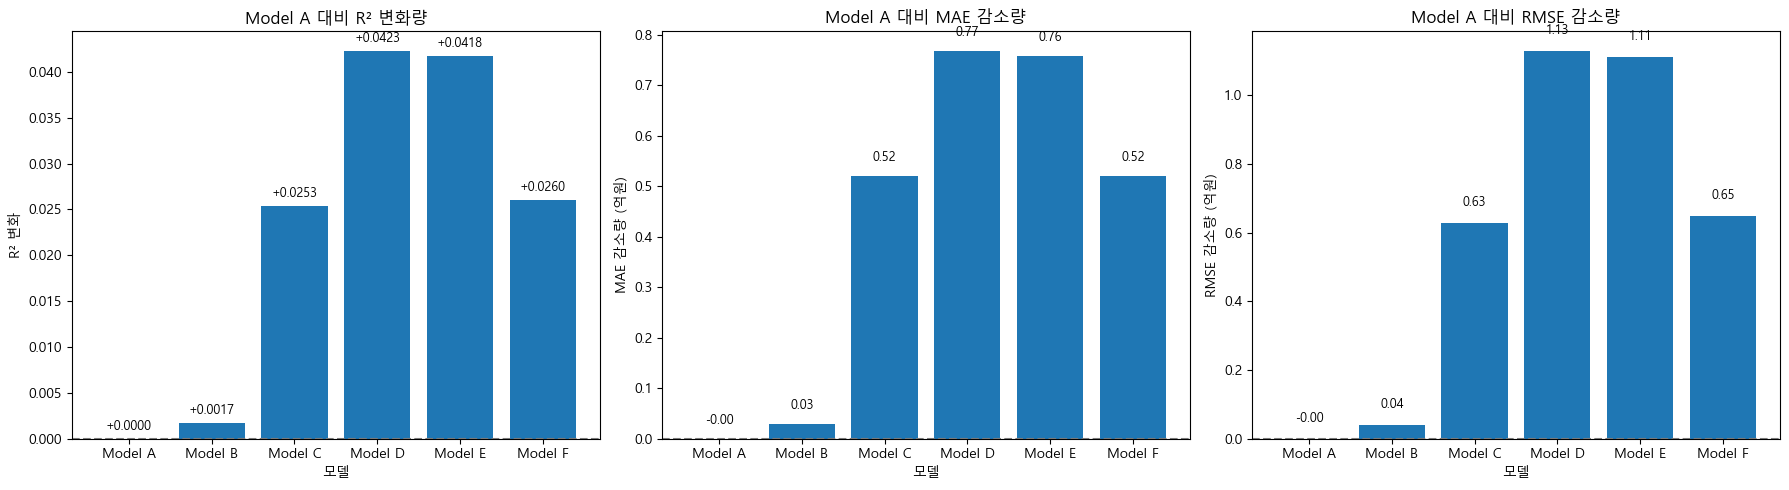

In [34]:
# ============================================================
# Model A 대비 R², MAE, RMSE 변화량 시각화
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# R² 변화량
r2_change = rf_comparison['R² 변화']
axes[0].bar(rf_comparison['모델'], r2_change)
axes[0].axhline(0, linestyle='--', color='gray')
axes[0].set_title('Model A 대비 R² 변화량')
axes[0].set_xlabel('모델')
axes[0].set_ylabel('R² 변화')
for i, value in enumerate(r2_change):
    axes[0].text(i, value + 0.001, f'{value:+.4f}', ha='center', fontsize=9)

# MAE 감소량
mae_reduction = -rf_comparison['MAE 변화'] / 10000
axes[1].bar(rf_comparison['모델'], mae_reduction)
axes[1].axhline(0, linestyle='--', color='gray')
axes[1].set_title('Model A 대비 MAE 감소량')
axes[1].set_xlabel('모델')
axes[1].set_ylabel('MAE 감소량 (억원)')
for i, value in enumerate(mae_reduction):
    axes[1].text(i, value + 0.03, f'{value:.2f}', ha='center', fontsize=9)

# RMSE 감소량
rmse_reduction = -rf_comparison['RMSE 변화'] / 10000
axes[2].bar(rf_comparison['모델'], rmse_reduction)
axes[2].axhline(0, linestyle='--', color='gray')
axes[2].set_title('Model A 대비 RMSE 감소량')
axes[2].set_xlabel('모델')
axes[2].set_ylabel('RMSE 감소량 (억원)')
for i, value in enumerate(rmse_reduction):
    axes[2].text(i, value + 0.05, f'{value:.2f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

### Model A 대비 성능 변화 해석

#### R² 변화량

- Model B(+0.0017): 역세권 변수 추가 시 성능 변화가 거의 없다. 동 단위 이진 변수의 한계로 세밀한 차이를 반영하지 못했기 때문이다.
- Model C(+0.0257): 학원수 추가 시 어느 정도 성능이 향상되었다.
- Model D(+0.0427): 사업체수 추가 시 단일 변수 중 가장 큰 성능 향상을 보였다.
- Model E(+0.0418): 세부 입지 변수 전부 추가 시 Model D와 거의 동일한 수준이다.
- Model F(+0.0262): 자치구 변수 추가 시 Model C와 비슷한 수준에 그쳤다.

#### MAE, RMSE 감소량

- Model D, E가 각각 0.77억, 0.76억으로 오차가 가장 많이 감소했다.
- Model B는 감소량이 0.03으로 역세권 변수의 실질적 효과가 거의 없었다.

#### 핵심 인사이트

- 역세권여부는 가격 예측에 거의 기여하지 못했다.
- 사업체수가 단일 입지 변수 중 가격 설명력에 가장 크게 기여했다.
- 세부 입지 변수 전체(Model E)가 자치구(Model F)보다 높은 성능을 보여 자치구 없이도 가격 예측이 가능함을 증명했다.


- Model A(주택 특성만)를 기준으로 입지 변수를 하나씩 추가했을 때 성능이 얼마나 오르는지 확인해서 어떤 입지 변수가 가격에 가장 큰 영향을 미치는지 수치로 증명하기 위해서 사용한다.


In [35]:
# ============================================================
# 성능 변화 해석용 출력
# ============================================================

for _, row in rf_comparison.iterrows():
    print(f'{row["모델"]}')
    print(f'  Test R² : {row["Test R²"]:.4f}')
    print(f'  R² 변화 : {row["R² 변화"]:+.4f}')
    print(f'  MAE     : {row["MAE"]:,.0f} 만원')
    print(f'  RMSE    : {row["RMSE"]:,.0f} 만원')
    print()

Model A
  Test R² : 0.9153
  R² 변화 : +0.0000
  MAE     : 17,168 만원
  RMSE    : 38,613 만원

Model B
  Test R² : 0.9171
  R² 변화 : +0.0017
  MAE     : 16,873 만원
  RMSE    : 38,217 만원

Model C
  Test R² : 0.9407
  R² 변화 : +0.0253
  MAE     : 11,960 만원
  RMSE    : 32,324 만원

Model D
  Test R² : 0.9576
  R² 변화 : +0.0423
  MAE     : 9,480 만원
  RMSE    : 27,316 만원

Model E
  Test R² : 0.9571
  R² 변화 : +0.0418
  MAE     : 9,583 만원
  RMSE    : 27,492 만원

Model F
  Test R² : 0.9413
  R² 변화 : +0.0260
  MAE     : 11,961 만원
  RMSE    : 32,142 만원



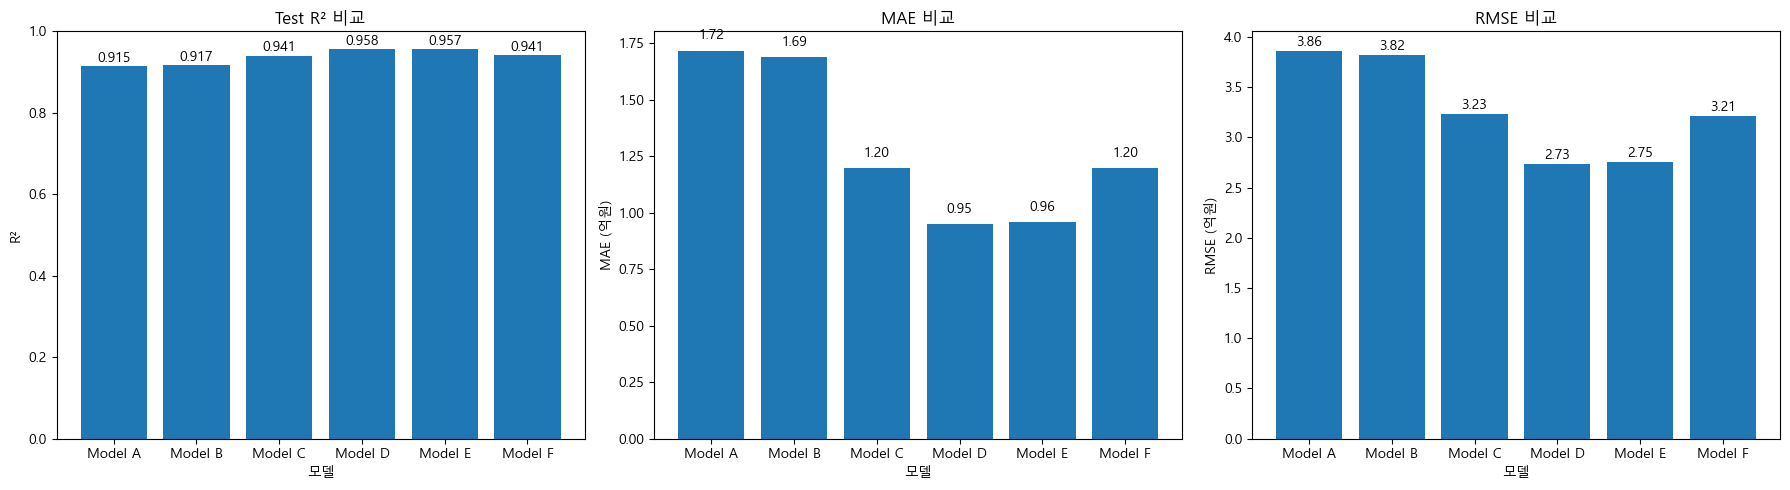

In [36]:
# ============================================================
# RandomForest Model A~F 성능 비교 종합 시각화
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# R²
axes[0].bar(rf_comparison['모델'], rf_comparison['Test R²'])
axes[0].set_title('Test R² 비교')
axes[0].set_xlabel('모델')
axes[0].set_ylabel('R²')
axes[0].set_ylim(0, 1)

for i, value in enumerate(rf_comparison['Test R²']):
    axes[0].text(i, value + 0.01, f'{value:.3f}', ha='center')

# MAE
mae_eok = rf_comparison['MAE'] / 10000
axes[1].bar(rf_comparison['모델'], mae_eok)
axes[1].set_title('MAE 비교')
axes[1].set_xlabel('모델')
axes[1].set_ylabel('MAE (억원)')

for i, value in enumerate(mae_eok):
    axes[1].text(i, value + 0.05, f'{value:.2f}', ha='center')

# RMSE
rmse_eok = rf_comparison['RMSE'] / 10000
axes[2].bar(rf_comparison['모델'], rmse_eok)
axes[2].set_title('RMSE 비교')
axes[2].set_xlabel('모델')
axes[2].set_ylabel('RMSE (억원)')

for i, value in enumerate(rmse_eok):
    axes[2].text(i, value + 0.05, f'{value:.2f}', ha='center')

plt.tight_layout()
plt.show()

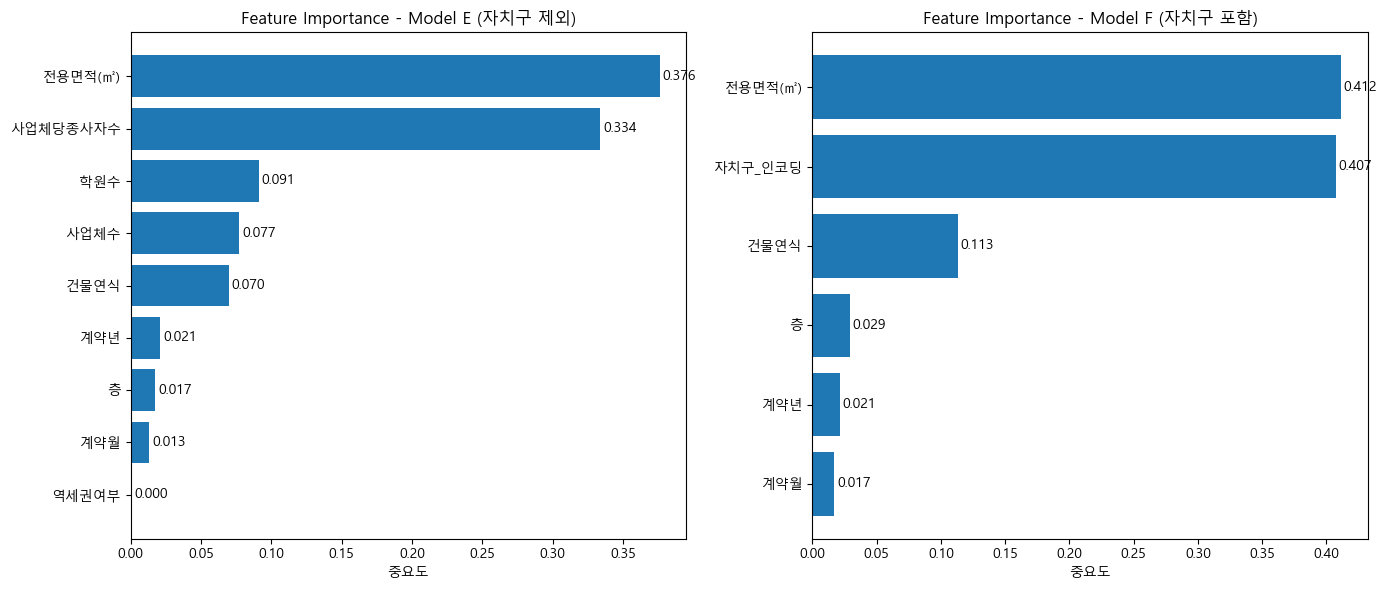

In [37]:
# ============================================================
# Feature Importance — Model E vs Model F 비교
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Model E
X_train_e = train_df[FEATURES_E]
rf_e = RandomForestRegressor(n_estimators=100, random_state=42)
rf_e.fit(X_train_e, y_train)

importance_e = pd.DataFrame({
    '변수': FEATURES_E,
    '중요도': rf_e.feature_importances_
}).sort_values('중요도', ascending=True)

axes[0].barh(importance_e['변수'], importance_e['중요도'])
axes[0].set_title('Feature Importance - Model E (자치구 제외)')
axes[0].set_xlabel('중요도')
for i, v in enumerate(importance_e['중요도']):
    axes[0].text(v + 0.002, i, f'{v:.3f}', va='center')

# Model F
X_train_f = train_df[FEATURES_F]
rf_f = RandomForestRegressor(n_estimators=100, random_state=42)
rf_f.fit(X_train_f, y_train)

importance_f = pd.DataFrame({
    '변수': FEATURES_F,
    '중요도': rf_f.feature_importances_
}).sort_values('중요도', ascending=True)

axes[1].barh(importance_f['변수'], importance_f['중요도'])
axes[1].set_title('Feature Importance - Model F (자치구 포함)')
axes[1].set_xlabel('중요도')
for i, v in enumerate(importance_f['중요도']):
    axes[1].text(v + 0.002, i, f'{v:.3f}', va='center')

plt.tight_layout()
plt.show()

랜덤포레스트가 어떤 변수를 중요하게 봤는지


1. Model E (자치구 없을 때)

- 가격을 결정하는 1등은 전용면적(집 크기), 2등은 사업체당종사자수이다. 역세권여부는 0.001로 거의 영향이 없다. 지하철 근처냐보다 그 동네에 얼마나 큰 회사들이 있냐가 가격에 더 중요하다는 것이다.

2. Model F (자치구 있을 때)

- 전용면적이랑 자치구\_인코딩이 0.412, 0.407로 거의 반반이다. "강남구냐 노원구냐"라는 정보 하나가 집 크기만큼이나 가격을 결정한다는 뜻이다.


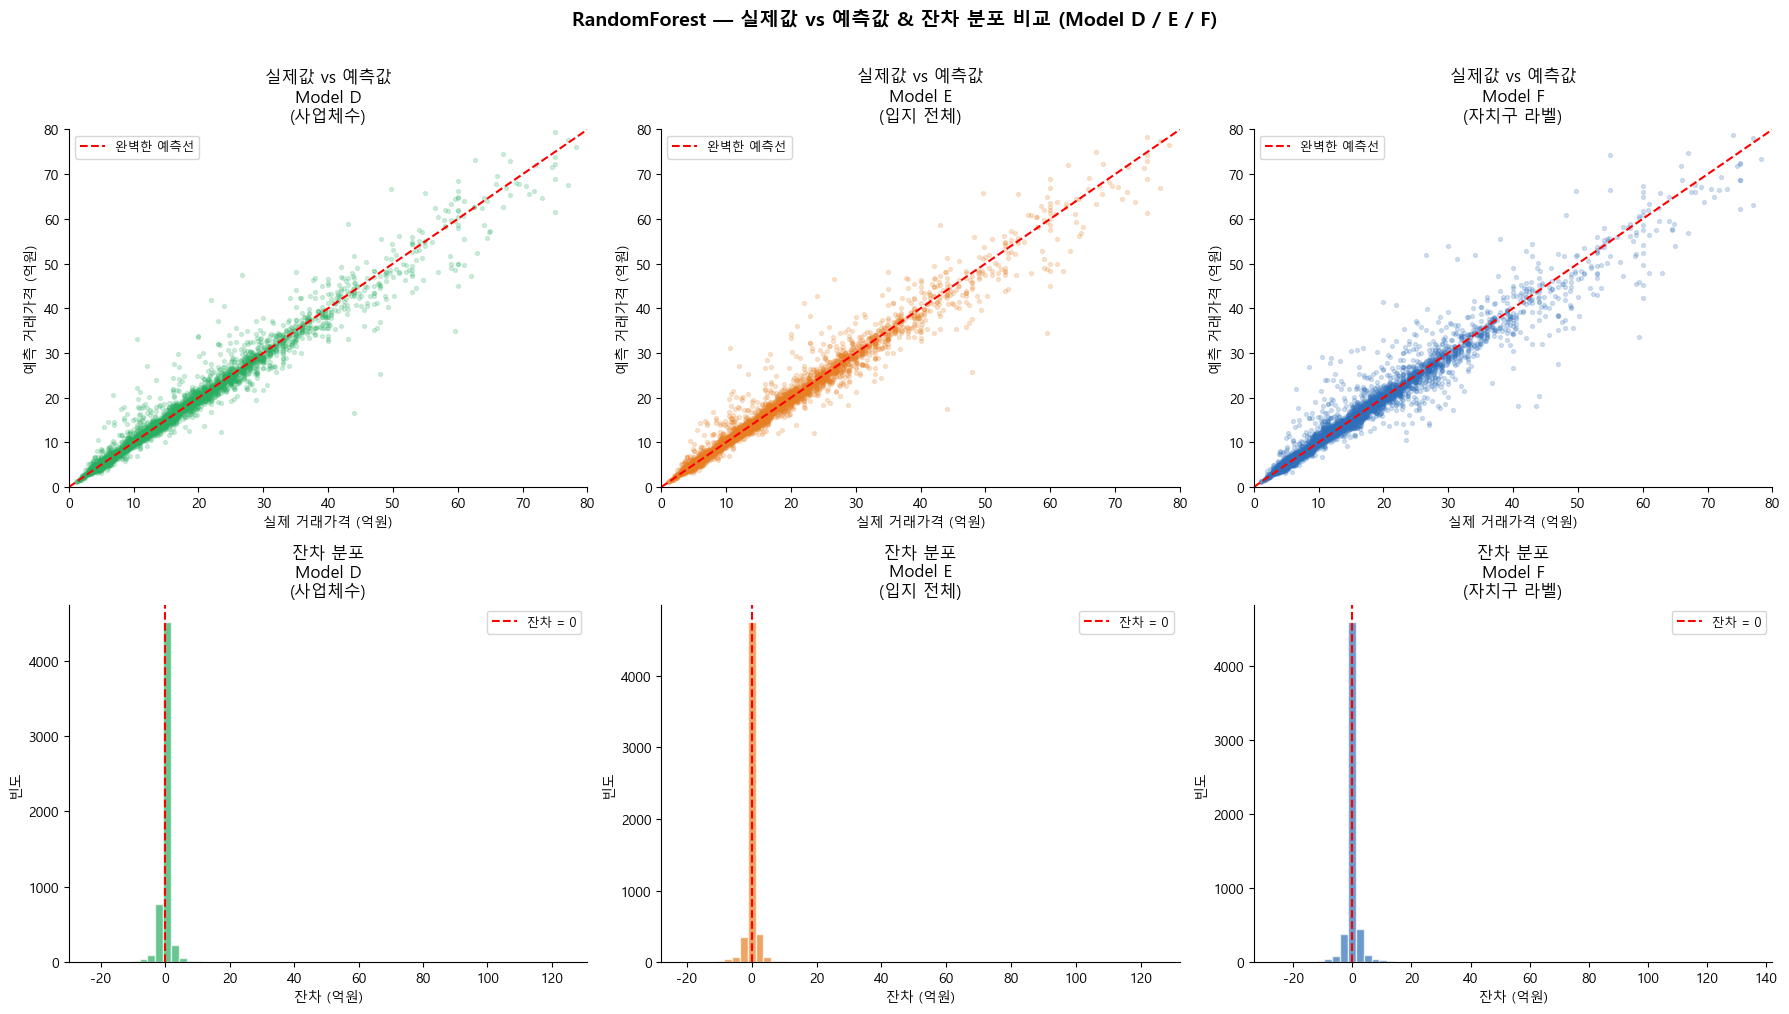

In [38]:
# ============================================================
# 실제값 vs 예측값 & 잔차 분포 (Model D / E / F 비교)
# ============================================================

from sklearn.ensemble import RandomForestRegressor

# 세 모델 재학습 및 예측
rf_d = RandomForestRegressor(n_estimators=100, random_state=42)
rf_d.fit(train_df[FEATURES_D], y_train)
y_pred_d = rf_d.predict(test_df[FEATURES_D])

rf_e = RandomForestRegressor(n_estimators=100, random_state=42)
rf_e.fit(train_df[FEATURES_E], y_train)
y_pred_e = rf_e.predict(test_df[FEATURES_E])

rf_f = RandomForestRegressor(n_estimators=100, random_state=42)
rf_f.fit(train_df[FEATURES_F], y_train)
y_pred_f = rf_f.predict(test_df[FEATURES_F])

models = [
    ('Model D\n(사업체수)', y_pred_d, '#27AE60'),
    ('Model E\n(입지 전체)', y_pred_e, '#E67E22'),
    ('Model F\n(자치구 라벨)', y_pred_f, '#2E6FBA'),
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for i, (label, y_pred, color) in enumerate(models):
    ax_scatter = axes[0][i]
    ax_hist    = axes[1][i]

    # 실제값 vs 예측값
    ax_scatter.scatter(y_test / 10000, y_pred / 10000,
                       alpha=0.2, s=8, color=color)
    ax_scatter.plot([0, 80], [0, 80], 'r--', linewidth=1.5, label='완벽한 예측선')
    ax_scatter.set_xlabel('실제 거래가격 (억원)')
    ax_scatter.set_ylabel('예측 거래가격 (억원)')
    ax_scatter.set_title(f'실제값 vs 예측값\n{label}', fontsize=12)
    ax_scatter.set_xlim(0, 80)
    ax_scatter.set_ylim(0, 80)
    ax_scatter.legend(fontsize=9)
    ax_scatter.spines['top'].set_visible(False)
    ax_scatter.spines['right'].set_visible(False)

    # 잔차 분포
    residuals = y_test - y_pred
    ax_hist.hist(residuals / 10000, bins=60,
                 color=color, alpha=0.7, edgecolor='white')
    ax_hist.axvline(0, color='r', linestyle='--', linewidth=1.5, label='잔차 = 0')
    ax_hist.set_xlabel('잔차 (억원)')
    ax_hist.set_ylabel('빈도')
    ax_hist.set_title(f'잔차 분포\n{label}', fontsize=12)
    ax_hist.legend(fontsize=9)
    ax_hist.spines['top'].set_visible(False)
    ax_hist.spines['right'].set_visible(False)

plt.suptitle('RandomForest — 실제값 vs 예측값 & 잔차 분포 비교 (Model D / E / F)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

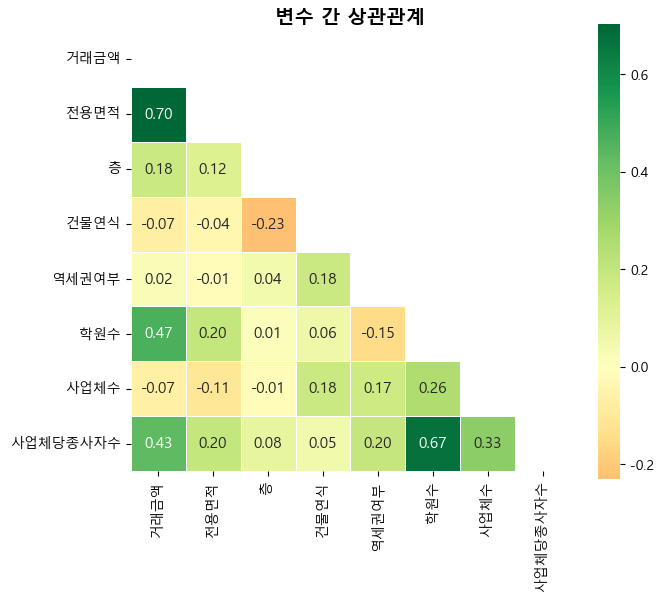

In [39]:
# ============================================================
# 상관관계 히트맵
# ============================================================

fig, ax = plt.subplots(figsize=(7, 6))

corr_cols = [
    '거래금액(만원)',
    '전용면적(㎡)',
    '층',
    '건물연식',
    '역세권여부',
    '학원수',
    '사업체수',
    '사업체당종사자수'
]

corr_data = df[corr_cols].copy()
corr_data.columns = [
    '거래금액',
    '전용면적',
    '층',
    '건물연식',
    '역세권여부',
    '학원수',
    '사업체수',
    '사업체당종사자수'
]

corr = corr_data.corr()

# 위쪽 삼각형 가리기
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    mask=mask,
    ax=ax,
    square=True,
    linewidths=0.5,
    annot_kws={'size': 11}
)

ax.set_title('변수 간 상관관계', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig(BASE_PATH + 'eda_corr.png', bbox_inches='tight', dpi=150)
plt.show()

**Model A~F 설명**
- Model A: 주택 특성 + 시점 변수
- Model B: Model A + 역세권여부
- Model C: Model A + 학원수
- Model D: Model A + 사업체수, 사업체당종사자수
- Model E: Model A + 세부 입지 변수 전체
- Model F: Model A + 자치구 인코딩

**해석 기준**
- R²는 높을수록 설명력이 높고, MAE와 RMSE는 낮을수록 예측 오차가 작다.
- Model A 대비 R²가 증가하고 MAE, RMSE가 감소하면 해당 변수 조합이 예측 성능 개선에 기여했다고 볼 수 있다.